# Notebook 04 — CMO Structuring & Waterfall Analysis

## Fixed Income From Scratch

**Objective:** Build CMO deals from first principles — take a single pool of mortgage collateral and carve it into tranches with fundamentally different risk profiles.

### Why CMOs Exist:
A pass-through MBS has one cash flow stream with one WAL, one duration, and one prepayment profile. But different investors want different things:
- **Money market funds** want short, predictable cash flows → **A tranche** (WAL ~3Y)
- **Insurance companies** want longer, stable cash flows → **PAC tranche** (protected from prepay variability)
- **Hedge funds** want leveraged rate bets → **IO strips** (negative duration) or **Companion tranches** (high vol)
- **Banks** want assets that match deposit funding → **Sequential tranches** at target WAL

CMO structuring solves this by redistributing the SAME collateral cash flows according to priority rules.

### Structures We'll Build:
1. **Sequential Pay** (with Z-bond) — The simplest CMO
2. **PAC / Companion** — The workhorse of the agency CMO market
3. **IO / PO Strips** — The purest expressions of prepayment risk

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys, os

sys.path.insert(0, os.path.abspath('..'))
from utils.cmo import (
    Tranche, TrancheType, TrancheFlows, CMOResult,
    run_sequential_cmo, run_pac_companion_cmo, strip_io_po,
    create_sequential_deal, generate_pac_schedule
)
from utils.cashflows import MBSPool, project_mbs_cashflows
from utils.prepayment import psa_to_cpr

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("CMO structuring modules loaded.")

CMO structuring modules loaded.


---
## 1. Collateral Pool Setup

Every CMO starts with collateral — a pool of mortgages whose cash flows will be redistributed. We'll use a $10 million FNMA 6.0% pool and project its cash flows at 150% PSA as the base case.

In [5]:
# Create collateral pool
pool = MBSPool(
    original_balance=10_000_000,
    current_balance=10_000_000,
    wac=0.065,
    net_coupon=0.060,
    wam=360,
    age=0,
    original_term=360
)

# Project at different PSA speeds (we'll need these for PAC analysis)
speeds = {'100 PSA': 100, '150 PSA': 150, '200 PSA': 200, '300 PSA': 300, '50 PSA': 50}
collateral = {}
for label, psa in speeds.items():
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    collateral[label] = {
        'cf': cf,
        'principal': cf.flows['total_principal'].values,
        'interest': cf.flows['net_interest'].values,
        'balance': cf.flows['beg_balance'].values
    }

cf_base = collateral['150 PSA']['cf']
print("Collateral Pool Summary")
print("=" * 50)
print(f"Balance:      ${pool.current_balance:>12,.0f}")
print(f"WAC:          {pool.wac*100:>11.2f}%")
print(f"Net Coupon:   {pool.net_coupon*100:>11.2f}%")
print(f"WAM:          {pool.wam:>9d} months")
print(f"\nAt 150% PSA:")
print(f"  WAL:        {cf_base.weighted_avg_life:>11.2f} years")
print(f"  Total Int:  ${cf_base.total_interest:>12,.0f}")
print(f"  Total Prin: ${cf_base.total_principal:>12,.0f}")

Collateral Pool Summary
Balance:      $  10,000,000
WAC:                 6.50%
Net Coupon:          6.00%
WAM:                360 months

At 150% PSA:
  WAL:               9.29 years
  Total Int:  $   5,571,003
  Total Prin: $  10,000,000


---
## 2. Sequential-Pay CMO with Z-Bond

### The Structure:
| Tranche | Balance | Coupon | Priority | Description |
|:--------|--------:|-------:|---------:|:------------|
| A | $4.0M | 6.0% | 1st | Short tranche — receives ALL principal first |
| B | $3.0M | 6.0% | 2nd | Mezzanine — starts receiving principal after A pays off |
| C | $2.0M | 6.0% | 3rd | Long tranche — receives principal after B |
| Z | $1.0M | 6.0% | Last | Accrual bond — accrues interest until A/B/C pay off |

### Z-Bond Mechanics:
The Z-bond is unique: during the "accrual period," its interest is NOT paid to the Z-bond holder. Instead, it's:
1. Added to the Z-bond's outstanding balance (accrual)
2. Redirected as additional principal to the senior tranches

This ACCELERATES the paydown of the A tranche (it receives collateral principal + Z-bond interest). Once A, B, and C are all paid off, the Z-bond starts receiving cash flows — by then, its balance has grown significantly from accrued interest.

In [8]:
# Create Sequential CMO with Z-bond
tranches = create_sequential_deal(
    collateral_balance=10_000_000,
    collateral_wac=0.060,
    tranche_splits={'A': 0.40, 'B': 0.30, 'C': 0.20, 'Z': 0.10},
    tranche_coupons={'A': 0.060, 'B': 0.060, 'C': 0.060, 'Z': 0.060},
    z_bond_name='Z'
)

# Run waterfall at 150% PSA
coll = collateral['150 PSA']
result = run_sequential_cmo(tranches, coll['principal'], coll['interest'], coll['balance'])

# Display summary
print("Sequential CMO Deal Summary (150% PSA)")
print("=" * 85)
summary = result.summary()
display_cols = ['Type', 'Orig Balance', 'Coupon (%)', 'WAL (Yrs)', 'First Prin Mo', 'Last Prin Mo']
print(summary[display_cols].to_string())

# Conservation check
check = result.conservation_check()
print(f"\nCash Flow Conservation: {'PASS' if check['is_conserved'] else 'FAIL'}")
print(f"  Total CF error: ${check['cf_error']:.2f}")
if check['tranche_principal'] > check['collateral_principal']:
    excess = check['tranche_principal'] - check['collateral_principal']
    print(f"  Z-bond accrued interest converted to principal: ${excess:,.0f}")

Sequential CMO Deal Summary (150% PSA)
               Type  Orig Balance  Coupon (%)  WAL (Yrs)  First Prin Mo  Last Prin Mo
Tranche                                                                              
A        sequential     4000000.0         6.0   2.977988              1            64
B        sequential     3000000.0         6.0   7.440936             64           118
C        sequential     2000000.0         6.0  11.793942            118           167
Z            z_bond     1000000.0         6.0  19.725451            167           360

Cash Flow Conservation: PASS
  Total CF error: $0.00
  Z-bond accrued interest converted to principal: $1,300,024


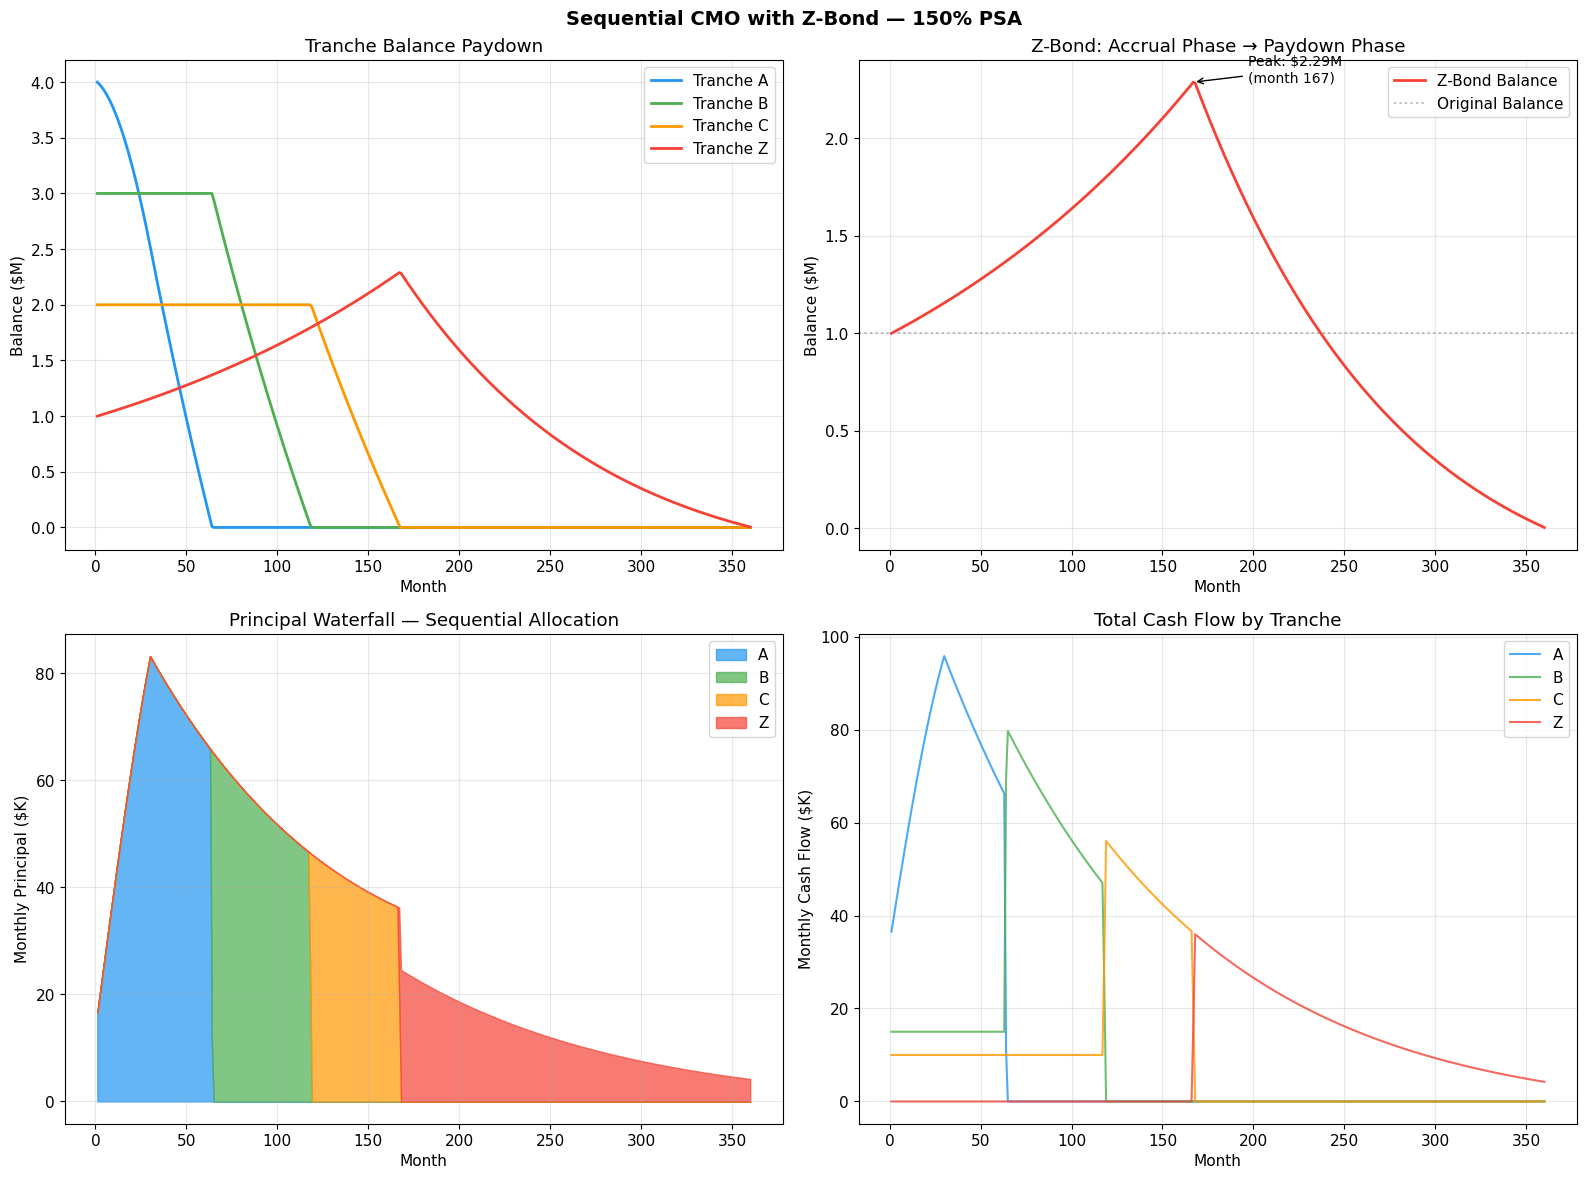

A tranche WAL: 3.0Y — short, predictable cash flows
Z-bond WAL: 19.7Y — very long, back-loaded cash flows
Z-bond balance grew from $1.0M to $2.29M before paydown began


In [10]:
# Visualize sequential waterfall
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
months = result.tranches['A'].months
colors = {'A': '#2196F3', 'B': '#4CAF50', 'C': '#FF9800', 'Z': '#F44336'}

# Tranche balances over time
ax = axes[0, 0]
for name in ['A', 'B', 'C', 'Z']:
    tf = result.tranches[name]
    ax.plot(months, tf.beg_balance / 1e6, linewidth=2, label=f'Tranche {name}', color=colors[name])
ax.set_xlabel('Month')
ax.set_ylabel('Balance ($M)')
ax.set_title('Tranche Balance Paydown')
ax.legend()

# Z-bond balance growth (accrual) then paydown
ax = axes[0, 1]
z = result.tranches['Z']
ax.plot(months, z.beg_balance / 1e6, linewidth=2, color='#F44336', label='Z-Bond Balance')
ax.axhline(y=z.original_balance / 1e6, color='gray', linestyle=':', alpha=0.5, label='Original Balance')
peak_bal = z.beg_balance.max()
peak_month = z.beg_balance.argmax() + 1
ax.annotate(f'Peak: ${peak_bal/1e6:.2f}M\n(month {peak_month})',
            xy=(peak_month, peak_bal/1e6), xytext=(peak_month+30, peak_bal/1e6),
            fontsize=10, arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('Month')
ax.set_ylabel('Balance ($M)')
ax.set_title('Z-Bond: Accrual Phase → Paydown Phase')
ax.legend()

# Monthly principal allocation
ax = axes[1, 0]
bottom = np.zeros(len(months))
for name in ['A', 'B', 'C', 'Z']:
    tf = result.tranches[name]
    ax.fill_between(months, bottom, bottom + tf.principal / 1e3, alpha=0.7, label=name, color=colors[name])
    bottom += tf.principal / 1e3
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Principal ($K)')
ax.set_title('Principal Waterfall — Sequential Allocation')
ax.legend()

# Monthly cash flows by tranche
ax = axes[1, 1]
for name in ['A', 'B', 'C', 'Z']:
    tf = result.tranches[name]
    ax.plot(months, tf.total_cashflow / 1e3, linewidth=1.5, label=name, color=colors[name], alpha=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Cash Flow ($K)')
ax.set_title('Total Cash Flow by Tranche')
ax.legend()

plt.suptitle('Sequential CMO with Z-Bond — 150% PSA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"A tranche WAL: {result.tranches['A'].weighted_avg_life:.1f}Y — short, predictable cash flows")
print(f"Z-bond WAL: {result.tranches['Z'].weighted_avg_life:.1f}Y — very long, back-loaded cash flows")
print(f"Z-bond balance grew from ${z.original_balance/1e6:.1f}M to ${peak_bal/1e6:.2f}M before paydown began")

---
## 3. Prepayment Sensitivity — How Tranching Redistributes Risk

The whole point of CMO structuring is to redistribute prepayment risk. Let's run the deal at different PSA speeds and see how each tranche's WAL changes.

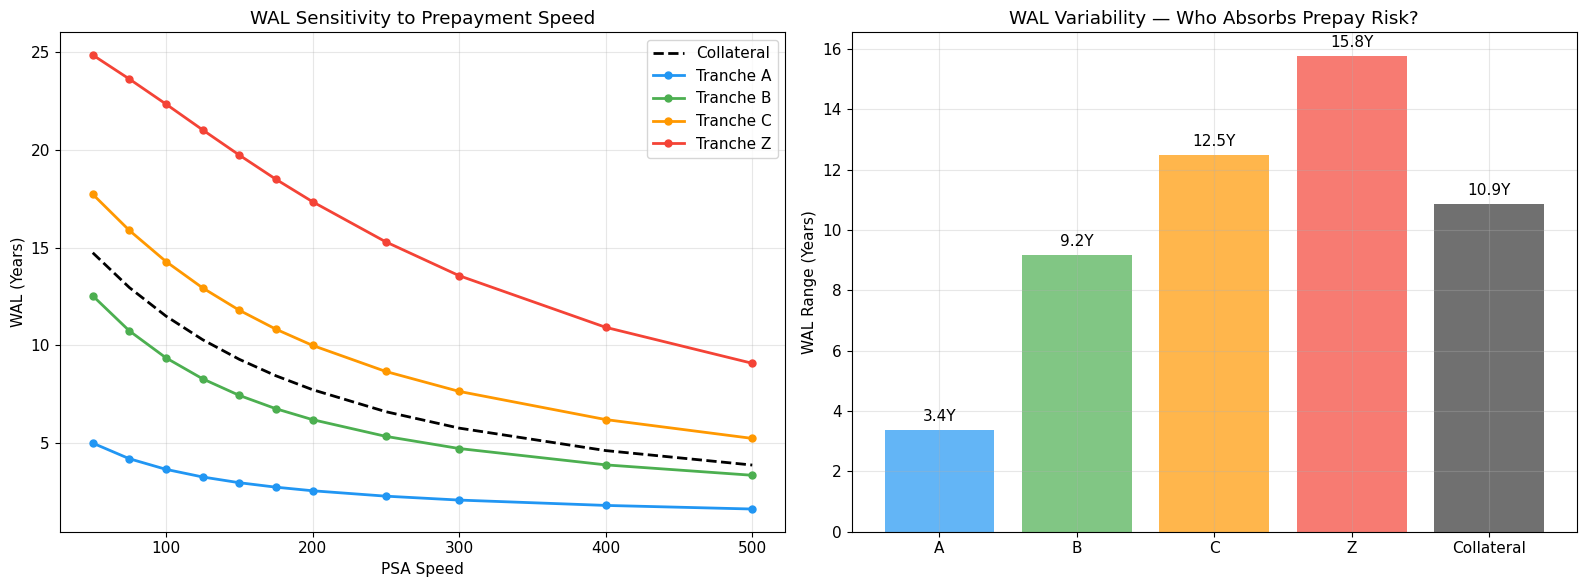

WAL Table (Years) by PSA Speed
   PSA  Collateral           A           B           C           Z
---------------------------------------------------------------------------
    50       14.73        5.00       12.53       17.72       24.84
    75       12.95        4.20       10.74       15.87       23.61
   100       11.49        3.66        9.36       14.28       22.33
   125       10.29        3.27        8.29       12.94       21.01
   150        9.29        2.98        7.44       11.79       19.73
   175        8.44        2.75        6.76       10.82       18.49
   200        7.73        2.57        6.20       10.00       17.34
   250        6.61        2.29        5.35        8.66       15.29
   300        5.77        2.09        4.73        7.65       13.56
   400        4.62        1.82        3.89        6.21       10.92
   500        3.88        1.63        3.36        5.24        9.08


In [13]:
# Run deal at multiple PSA speeds
psa_range = [50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500]
wal_table = {name: [] for name in ['A', 'B', 'C', 'Z', 'Collateral']}

for psa in psa_range:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    wal_table['Collateral'].append(cf.weighted_avg_life)
    
    coll_prin = cf.flows['total_principal'].values
    coll_int = cf.flows['net_interest'].values
    coll_bal = cf.flows['beg_balance'].values
    
    res = run_sequential_cmo(tranches, coll_prin, coll_int, coll_bal)
    for name in ['A', 'B', 'C', 'Z']:
        wal_table[name].append(res.tranches[name].weighted_avg_life)

# Plot WAL sensitivity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(psa_range, wal_table['Collateral'], 'k--', linewidth=2, label='Collateral')
for name, color in [('A', '#2196F3'), ('B', '#4CAF50'), ('C', '#FF9800'), ('Z', '#F44336')]:
    ax1.plot(psa_range, wal_table[name], 'o-', linewidth=2, label=f'Tranche {name}', color=color, markersize=5)
ax1.set_xlabel('PSA Speed')
ax1.set_ylabel('WAL (Years)')
ax1.set_title('WAL Sensitivity to Prepayment Speed')
ax1.legend()

# WAL variability (range) — who absorbs the most prepay risk?
ax2_data = {}
for name in ['A', 'B', 'C', 'Z', 'Collateral']:
    wals = wal_table[name]
    ax2_data[name] = max(wals) - min(wals)

bars = ax2.bar(ax2_data.keys(), ax2_data.values(), 
               color=['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#333333'], alpha=0.7)
ax2.set_ylabel('WAL Range (Years)')
ax2.set_title('WAL Variability — Who Absorbs Prepay Risk?')
for bar, val in zip(bars, ax2_data.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}Y', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Print WAL table
print("WAL Table (Years) by PSA Speed")
print("=" * 75)
print(f"{'PSA':>6}", end='')
for name in ['Collateral', 'A', 'B', 'C', 'Z']:
    print(f"{name:>12}", end='')
print()
print("-" * 75)
for i, psa in enumerate(psa_range):
    print(f"{psa:>6}", end='')
    for name in ['Collateral', 'A', 'B', 'C', 'Z']:
        print(f"{wal_table[name][i]:>12.2f}", end='')
    print()

---
## 4. PAC / Companion Structure

### The PAC Concept:
A **Planned Amortization Class (PAC)** tranche has a defined principal payment schedule that is maintained as long as actual prepayments stay within a band (e.g., 100-300 PSA).

The **Companion** tranche absorbs ALL the variability:
- **Fast prepays**: companion receives excess principal (shortens)
- **Slow prepays**: companion receives less principal (extends)
- The PAC holder is protected from both directions

### PAC Schedule Construction:
1. Project collateral cash flows at the LOWER band (100 PSA) → get principal_low
2. Project at the UPPER band (300 PSA) → get principal_high
3. PAC schedule = MINIMUM of principal_low and principal_high at each month
4. This is the schedule that works under BOTH extremes

The companion absorbs the difference: (actual principal - PAC schedule) when positive.

In [16]:
# Generate PAC schedule
pac_schedule = generate_pac_schedule(
    collateral_balance=10_000_000,
    collateral_wac=0.065,
    collateral_wam=360,
    collateral_age=0,
    lower_psa=100,
    upper_psa=300,
    pac_balance=6_000_000
)

# Create PAC/Companion tranches
pac_tranche = Tranche('PAC', TrancheType.PAC, 6_000_000, 0.060, 0, pac_schedule, 300, 100)
companion_tranche = Tranche('Companion', TrancheType.COMPANION, 4_000_000, 0.060, 1)

# Run at base case (150 PSA — within the bands)
coll = collateral['150 PSA']
pac_result = run_pac_companion_cmo(
    pac_tranche, companion_tranche, [],
    coll['principal'], coll['interest'], coll['balance'], pac_schedule
)

print("PAC/Companion Deal Summary (150% PSA — Within Bands)")
print("=" * 75)
print(pac_result.summary()[['Type', 'Orig Balance', 'WAL (Yrs)', 'First Prin Mo', 'Last Prin Mo']].to_string())
print(f"\nPAC Bands: {100}-{300} PSA")
print(f"PAC schedule sum: ${pac_schedule.sum():,.0f}")

PAC/Companion Deal Summary (150% PSA — Within Bands)
                Type  Orig Balance  WAL (Yrs)  First Prin Mo  Last Prin Mo
Tranche                                                                   
PAC              pac       6000000   6.211047              1           179
Companion  companion       4000000  13.895941              1           360

PAC Bands: 100-300 PSA
PAC schedule sum: $6,000,000


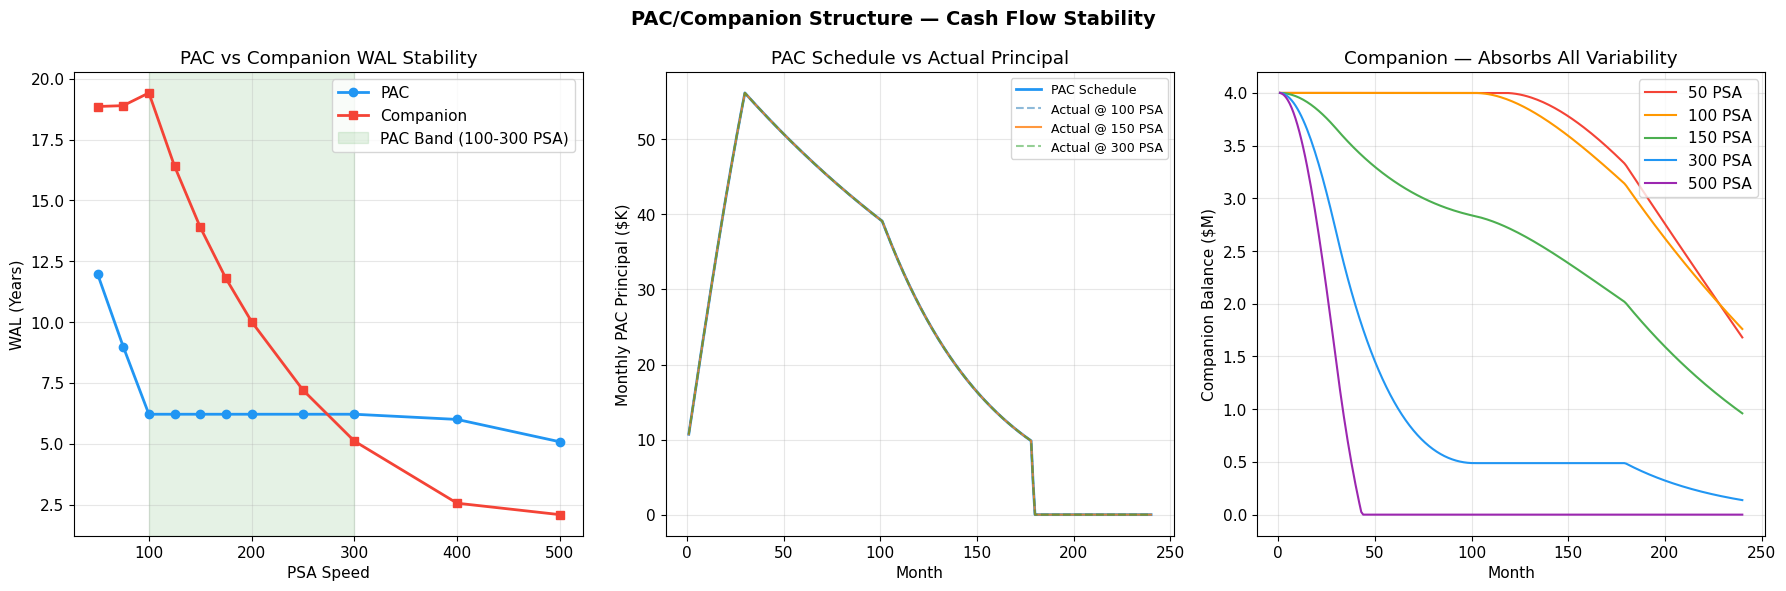

PAC WAL range across all speeds:       6.90 years
Companion WAL range across all speeds:  17.33 years

The PAC has 2.5x less WAL variability than the Companion.
This stability is why PAC bonds trade at tighter OAS than Companions.


In [18]:
# Run PAC/Companion at multiple speeds to show protection
pac_speeds = [50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500]
pac_wals = []
comp_wals = []

for psa in pac_speeds:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    res = run_pac_companion_cmo(
        pac_tranche, companion_tranche, [],
        cf.flows['total_principal'].values,
        cf.flows['net_interest'].values,
        cf.flows['beg_balance'].values,
        pac_schedule
    )
    pac_wals.append(res.tranches['PAC'].weighted_avg_life)
    comp_wals.append(res.tranches['Companion'].weighted_avg_life)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# WAL comparison
ax = axes[0]
ax.plot(pac_speeds, pac_wals, 'o-', linewidth=2, markersize=6, label='PAC', color='#2196F3')
ax.plot(pac_speeds, comp_wals, 's-', linewidth=2, markersize=6, label='Companion', color='#F44336')
ax.axvspan(100, 300, alpha=0.1, color='green', label='PAC Band (100-300 PSA)')
ax.set_xlabel('PSA Speed')
ax.set_ylabel('WAL (Years)')
ax.set_title('PAC vs Companion WAL Stability')
ax.legend()

# PAC schedule vs actual
ax = axes[1]
months = np.arange(1, len(pac_schedule) + 1)
ax.plot(months[:240], pac_schedule[:240] / 1e3, linewidth=2, label='PAC Schedule', color='#2196F3')
# Show actual PAC principal at different speeds
for psa, ls, alpha in [(100, '--', 0.5), (150, '-', 0.8), (300, '--', 0.5)]:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    res = run_pac_companion_cmo(
        pac_tranche, companion_tranche, [],
        cf.flows['total_principal'].values,
        cf.flows['net_interest'].values,
        cf.flows['beg_balance'].values,
        pac_schedule
    )
    pac_prin = res.tranches['PAC'].principal
    ax.plot(np.arange(1, len(pac_prin)+1)[:240], pac_prin[:240] / 1e3, ls, 
            alpha=alpha, label=f'Actual @ {psa} PSA', linewidth=1.5)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly PAC Principal ($K)')
ax.set_title('PAC Schedule vs Actual Principal')
ax.legend(fontsize=9)

# Companion as shock absorber
ax = axes[2]
for psa, color in [(50, '#F44336'), (100, '#FF9800'), (150, '#4CAF50'), (300, '#2196F3'), (500, '#9C27B0')]:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    res = run_pac_companion_cmo(
        pac_tranche, companion_tranche, [],
        cf.flows['total_principal'].values,
        cf.flows['net_interest'].values,
        cf.flows['beg_balance'].values,
        pac_schedule
    )
    comp = res.tranches['Companion']
    ax.plot(comp.months[:240], comp.beg_balance[:240] / 1e6, linewidth=1.5, label=f'{psa} PSA', color=color)
ax.set_xlabel('Month')
ax.set_ylabel('Companion Balance ($M)')
ax.set_title('Companion — Absorbs All Variability')
ax.legend()

plt.suptitle('PAC/Companion Structure — Cash Flow Stability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
pac_wal_range = max(pac_wals) - min(pac_wals)
comp_wal_range = max(comp_wals) - min(comp_wals)
print(f"PAC WAL range across all speeds:       {pac_wal_range:.2f} years")
print(f"Companion WAL range across all speeds:  {comp_wal_range:.2f} years")
print(f"\nThe PAC has {comp_wal_range/pac_wal_range:.1f}x less WAL variability than the Companion.")
print("This stability is why PAC bonds trade at tighter OAS than Companions.")

---
## 5. IO/PO Strips — Pure Prepayment Bets

IO (Interest-Only) and PO (Principal-Only) strips separate the collateral into its two fundamental cash flow components. They have **opposite** prepayment sensitivities:

| Strip | Receives | Fast Prepays | Slow Prepays | Duration |
|:------|:---------|:-------------|:-------------|:---------|
| **IO** | All interest | BAD (less balance → less interest) | GOOD (balance persists → more interest) | **Negative** |
| **PO** | All principal | GOOD (get principal back sooner) | BAD (principal delayed) | **Very long** |

IO strips are one of the few instruments with **negative duration** — they gain value when rates RISE (because rising rates slow prepayments, preserving the interest stream). This makes IOs a unique hedging tool for mortgage portfolios.

IO/PO Strip Summary (150% PSA)
IO Strip: WAL = 7.20Y, Total CF = $5,571,003
PO Strip: WAL = 9.29Y, Total CF = $10,000,000
Sum of IO + PO = $15,571,003
Collateral CF  = $15,571,003


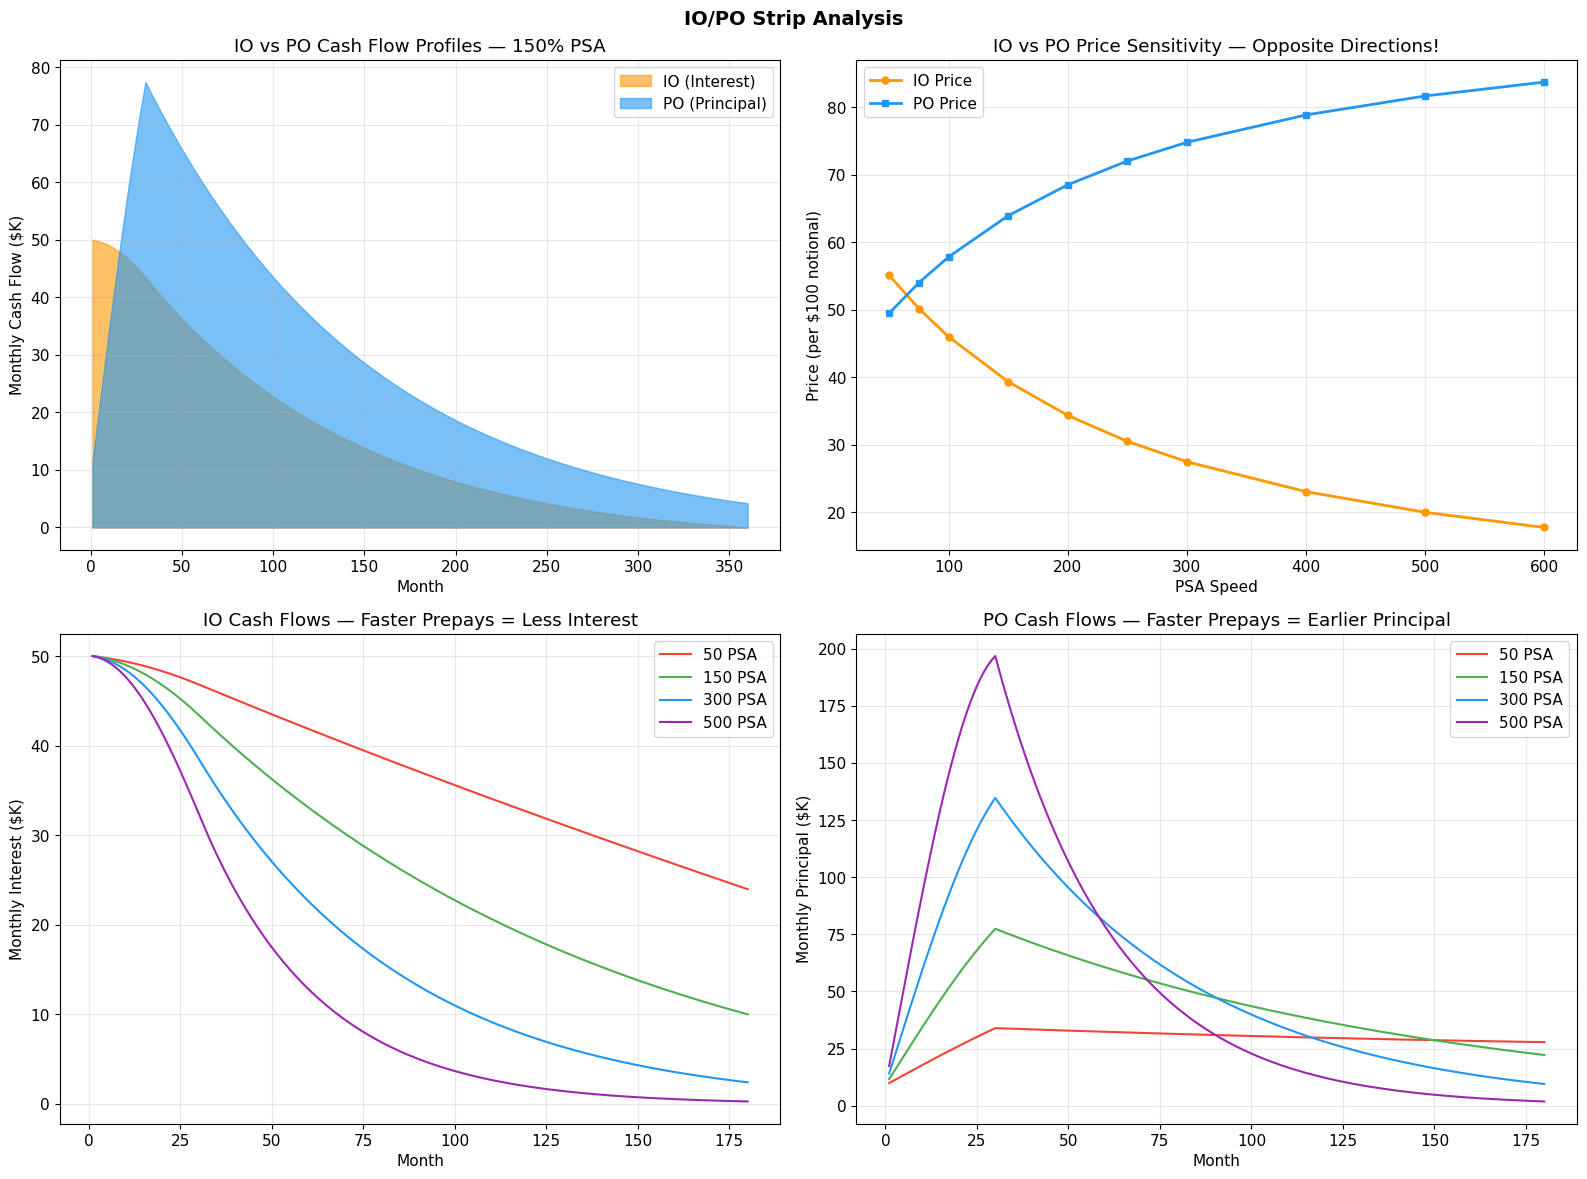

IO price FALLS as prepays increase — negative duration (unique to IOs)
PO price RISES as prepays increase — very long effective duration

This is why IOs are used to hedge mortgage servicing rights (MSRs)
and why POs are pure bets on falling rates.


In [21]:
# Create IO/PO strips
coll = collateral['150 PSA']
io_po = strip_io_po(coll['principal'], coll['interest'], coll['balance'], 10_000_000)

print("IO/PO Strip Summary (150% PSA)")
print("=" * 55)
io = io_po.tranches['IO']
po = io_po.tranches['PO']
print(f"IO Strip: WAL = {io.weighted_avg_life:.2f}Y, Total CF = ${io.total_interest:,.0f}")
print(f"PO Strip: WAL = {po.weighted_avg_life:.2f}Y, Total CF = ${po.total_principal:,.0f}")
print(f"Sum of IO + PO = ${io.total_interest + po.total_principal:,.0f}")
print(f"Collateral CF  = ${coll['interest'].sum() + coll['principal'].sum():,.0f}")

# Sensitivity analysis
io_values = []
po_values = []
psa_range_strip = [50, 75, 100, 150, 200, 250, 300, 400, 500, 600]
discount_rate = 0.055  # Flat discount rate for comparison

for psa in psa_range_strip:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    strip = strip_io_po(cf.flows['total_principal'].values, 
                         cf.flows['net_interest'].values,
                         cf.flows['beg_balance'].values, 10_000_000)
    
    # Simple PV using flat discount rate
    months = strip.tranches['IO'].months
    df = (1 + discount_rate/12) ** (-months)
    
    io_pv = np.sum(strip.tranches['IO'].interest * df)
    po_pv = np.sum(strip.tranches['PO'].principal * df)
    
    io_values.append(io_pv / 10_000_000 * 100)
    po_values.append(po_pv / 10_000_000 * 100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# IO/PO cash flows at 150 PSA
ax = axes[0, 0]
ax.fill_between(io.months, 0, io.interest / 1e3, alpha=0.6, label='IO (Interest)', color='#FF9800')
ax.fill_between(po.months, 0, po.principal / 1e3, alpha=0.6, label='PO (Principal)', color='#2196F3')
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Cash Flow ($K)')
ax.set_title('IO vs PO Cash Flow Profiles — 150% PSA')
ax.legend()

# Price sensitivity to PSA
ax = axes[0, 1]
ax.plot(psa_range_strip, io_values, 'o-', linewidth=2, label='IO Price', color='#FF9800', markersize=5)
ax.plot(psa_range_strip, po_values, 's-', linewidth=2, label='PO Price', color='#2196F3', markersize=5)
ax.set_xlabel('PSA Speed')
ax.set_ylabel('Price (per $100 notional)')
ax.set_title('IO vs PO Price Sensitivity — Opposite Directions!')
ax.legend()

# IO cash flows across speeds
ax = axes[1, 0]
for psa, color in [(50, '#F44336'), (150, '#4CAF50'), (300, '#2196F3'), (500, '#9C27B0')]:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    ax.plot(cf.flows['month'][:180], cf.flows['net_interest'].values[:180] / 1e3, 
            linewidth=1.5, label=f'{psa} PSA', color=color)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Interest ($K)')
ax.set_title('IO Cash Flows — Faster Prepays = Less Interest')
ax.legend()

# PO cash flows across speeds
ax = axes[1, 1]
for psa, color in [(50, '#F44336'), (150, '#4CAF50'), (300, '#2196F3'), (500, '#9C27B0')]:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    ax.plot(cf.flows['month'][:180], cf.flows['total_principal'].values[:180] / 1e3,
            linewidth=1.5, label=f'{psa} PSA', color=color)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Principal ($K)')
ax.set_title('PO Cash Flows — Faster Prepays = Earlier Principal')
ax.legend()

plt.suptitle('IO/PO Strip Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("IO price FALLS as prepays increase — negative duration (unique to IOs)")
print("PO price RISES as prepays increase — very long effective duration")
print("\nThis is why IOs are used to hedge mortgage servicing rights (MSRs)")
print("and why POs are pure bets on falling rates.")

---
## 6. Deal Comparison — Putting It All Together

Let's compare how the same collateral gets transformed by different structuring choices.

In [24]:
# Run all structures at 150 PSA
coll = collateral['150 PSA']
coll_p = coll['principal']
coll_i = coll['interest']
coll_b = coll['balance']

# Sequential (no Z)
seq_tranches = create_sequential_deal(
    10_000_000, 0.060,
    {'A': 0.35, 'B': 0.30, 'C': 0.35},
    {'A': 0.060, 'B': 0.060, 'C': 0.060}
)
seq_result = run_sequential_cmo(seq_tranches, coll_p, coll_i, coll_b)

# PAC/Companion  
pac_sched = generate_pac_schedule(10_000_000, 0.065, 360, 0, 100, 300, 6_000_000)
pac_t = Tranche('PAC', TrancheType.PAC, 6_000_000, 0.060, 0, pac_sched, 300, 100)
comp_t = Tranche('Comp', TrancheType.COMPANION, 4_000_000, 0.060, 1)
pac_result = run_pac_companion_cmo(pac_t, comp_t, [], coll_p, coll_i, coll_b, pac_sched)

# IO/PO
io_po_result = strip_io_po(coll_p, coll_i, coll_b, 10_000_000)

# Comprehensive comparison
print("Comprehensive Deal Comparison — 150% PSA")
print("=" * 80)
print(f"{'Tranche':<15} {'Structure':<15} {'Balance ($M)':>12} {'WAL (Yrs)':>10} {'Window':>12}")
print("-" * 80)

# Pass-through
print(f"{'Pass-Through':<15} {'None':<15} {'10.00':>12} {cf_base.weighted_avg_life:>10.2f} {'1-360':>12}")
print()

# Sequential
for name in ['A', 'B', 'C']:
    tf = seq_result.tranches[name]
    w = tf.window
    print(f"{'Seq-' + name:<15} {'Sequential':<15} {tf.original_balance/1e6:>12.2f} {tf.weighted_avg_life:>10.2f} {f'{w[0]}-{w[1]}':>12}")
print()

# PAC/Companion
for name in ['PAC', 'Comp']:
    tf = pac_result.tranches[name]
    w = tf.window
    print(f"{name:<15} {'PAC/Comp':<15} {tf.original_balance/1e6:>12.2f} {tf.weighted_avg_life:>10.2f} {f'{w[0]}-{w[1]}':>12}")
print()

# IO/PO
for name in ['IO', 'PO']:
    tf = io_po_result.tranches[name]
    w = tf.window if name == 'PO' else (1, len(coll_p))
    wal = tf.weighted_avg_life
    print(f"{name:<15} {'Strip':<15} {'10.00 (N)':>12} {wal:>10.2f} {f'{w[0]}-{w[1]}':>12}")

print()
print("KEY INSIGHT: The same $10M collateral with WAL 9.3Y has been transformed into:")
print("  - Short (Seq-A: 3.1Y) to long (Seq-C: 17.6Y) sequential tranches")
print("  - Stable (PAC: protected WAL) vs volatile (Companion) cash flows")
print("  - Opposite-directional bets (IO: negative duration vs PO: long duration)")
print("\nThis is financial engineering: redistributing risk, not eliminating it.")

Comprehensive Deal Comparison — 150% PSA
Tranche         Structure       Balance ($M)  WAL (Yrs)       Window
--------------------------------------------------------------------------------
Pass-Through    None                   10.00       9.29        1-360

Seq-A           Sequential              3.50       2.91         1-61
Seq-B           Sequential              3.00       7.58       61-126
Seq-C           Sequential              3.50      17.12      126-360

PAC             PAC/Comp                6.00       6.21        1-179
Comp            PAC/Comp                4.00      13.90        1-360

IO              Strip              10.00 (N)       7.20        1-360
PO              Strip              10.00 (N)       9.29        1-360

KEY INSIGHT: The same $10M collateral with WAL 9.3Y has been transformed into:
  - Short (Seq-A: 3.1Y) to long (Seq-C: 17.6Y) sequential tranches
  - Stable (PAC: protected WAL) vs volatile (Companion) cash flows
  - Opposite-directional bets (IO: negat

---
## Summary & What's Next

### What We Built:
- **Sequential CMO waterfall** with Z-bond accrual mechanics and verified cash flow conservation
- **PAC/Companion structure** with PAC schedule generation from upper/lower bands
- **IO/PO strip engine** demonstrating opposite prepayment sensitivities
- **Comprehensive analysis** showing WAL stability (PAC) vs variability (Companion/Sequential)

### Key Structural Insights Demonstrated:
- Z-bond accrual redirects interest to accelerate senior tranche paydown
- PAC WAL is stable within bands; Companion absorbs all variability
- IO has negative effective duration (gains when rates rise)
- CMO structuring redistributes prepayment risk — it doesn't eliminate it

### Coming in Phase 3:
- **Notebook 05**: Volatility surfaces (swaption vols, SABR calibration)
- **Notebook 06**: BGM 3-factor interest rate model and Monte Carlo path generation
- **Notebook 07**: OAS calculation with all risk measures (the culmination of everything built so far)